# **Data Analytics Using Python Mini Project**

#### **Name : Sujal Jaiswal**
#### **Roll No : 240662**
#### **Section : Cse 6**
#### **Course Name : Data Analytics Using Python**
#### **Course Code: CSE2101**


# **Step 1: Problem Definition & Dataset Selection**

### **Objective**
To analyze used cars listed on CarDekho and discover natural groups (clusters) based on:
- Selling Price
- Age of Car
- Kms Driven
- Fuel Type
- Transmission
- Owner Type

This helps understand buyer segments, car conditions, and pricing patterns.

### **Dataset Source**
- **File:** CAR DETAILS FROM CAR DEKHO.csv  
- **Platform:** Kaggle (commonly available dataset)  
- **Description:** Contains details of various used cars such as model, price, mileage, fuel type, and year.

### **Dataset Overview**
We will:
- Load dataset  
- Inspect rows, columns, and structure  
- Identify numerical and categorical features  


In [32]:
import pandas as pd

# Load dataset
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

# Display first few rows
df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


**Shape**

In [3]:
# Shape of dataset
df.shape


(4340, 8)

**Dataset overview (rows, columns, features)**


In [4]:
# Info about columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


**Statistical summary**



In [5]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


# **Step 2: Data Cleaning & Preparation**

In this step, we perform all necessary preprocessing before clustering.  
We will check:

1. Missing values  
2. Duplicate rows  
3. Outliers  
4. Encoding categorical features  
5. Feature engineering (Age of car)  
6. Scaling numeric columns  

Each preprocessing step is justified below.

In [6]:
# Check missing values
df.isnull().sum()


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

### Justification -  Handling Missing Values
The dataset does not contain missing values (as visible from the output).  
Therefore, no imputation or deletion is needed.


In [33]:
# Count duplicates
df.duplicated().sum()


np.int64(763)

In [8]:
# Remove duplicates if any
df = df.drop_duplicates()


### Justification - Handling Duplicates
Duplicate entries can distort clustering results,  
so duplicate rows are removed to ensure clean data.


## **Feature Engineering — Creating Age Column**

K-Means requires numerical features, so we convert "Year" → "Age".

In [9]:
from datetime import datetime

current_year = datetime.now().year

# Create new Age column
df['Age'] = current_year - df['year']

# Drop original year column
df = df.drop('year', axis=1)

df[['Age']].head()


,Age
0,18
1,18
2,13
3,8
4,11


### Justification - Creating Age Feature
K-Means clustering works better when features reflect real-world meaning.  
"Age" is more interpretable than "Year", and helps group cars based on usage/condition.


## **Encoding Categorical Data**

"K-Means only works with numbers", so we convert:

Fuel type

Seller type

Transmission

Owner

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['fuel'] = le.fit_transform(df['fuel'])
df['seller_type'] = le.fit_transform(df['seller_type'])
df['transmission'] = le.fit_transform(df['transmission'])
df['owner'] = le.fit_transform(df['owner'])


### Justification - Encoding Categorical Columns
K-Means requires numerical data.  
Label Encoding converts categories like Fuel Type and Transmission into machine-readable values.


## **Outlier Handling (IQR Method)**

We mainly check for outliers in:

Selling Price

Kms Driven

In [11]:
import numpy as np

def remove_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

# Remove outliers from price and kms driven
df = remove_outliers('selling_price')
df = remove_outliers('km_driven')

df.shape


(3287, 8)

### Justification - Handling Outliers
Outliers distort cluster boundaries.  
Using the IQR rule ensures the clusters represent typical car behavior, not rare extreme values.


## **Scaling the Dataset (Required for K-Means)**

K-Means uses Euclidean distance → scaling is mandatory.

We scale:

Selling Price

Km Driven

Age

Fuel

Transmission

Owner

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select features for clustering
X = df[['selling_price', 'km_driven', 'Age', 'fuel', 'transmission', 'owner']]

# Scale data
X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[-1.31316735,  0.14196784,  1.38148808,  0.9665037 ,  0.25044416,
        -0.71732444],
       [-1.01717317, -0.41441622,  1.38148808,  0.9665037 ,  0.25044416,
        -0.71732444],
       [ 0.81799069,  0.97654394,  0.20866115, -1.02029909,  0.25044416,
        -0.71732444],
       [-0.56331545, -0.52569304, -0.96416579,  0.9665037 ,  0.25044416,
        -0.71732444],
       [ 0.22600234,  2.11713128, -0.26046963, -1.02029909,  0.25044416,
         0.85930239]])

### Justification -Scaling the Data
All features must be on the same scale so that none of them dominates the clustering process.  
StandardScaler converts all variables to mean = 0 and standard deviation = 1.


# **Step 3: Exploratory Data Analysis (EDA)**

EDA helps us understand patterns, trends, and relationships among variables.  
We’ll perform:

1. **Univariate Analysis** → Distribution of individual features  
2. **Bivariate Analysis** → Relationships between features  
3. **Multivariate Analysis** → Correlation among all numerical features  

Each visualization will be followed by a short **inference**.


**Univariate Analysis**

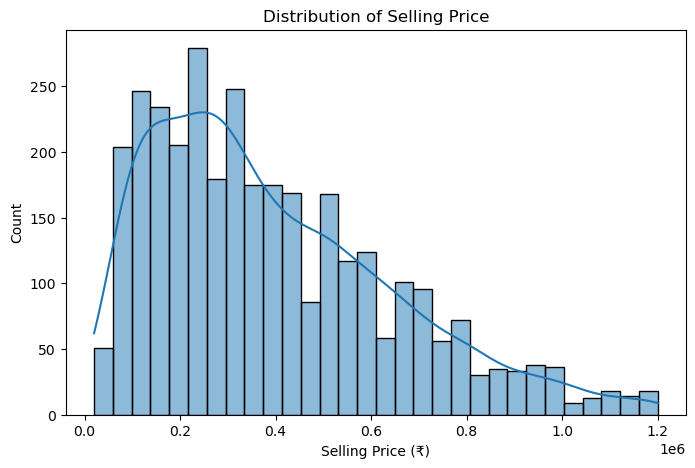

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['selling_price'], bins=30, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (₹)")
plt.ylabel("Count")
plt.show()


### 🔍 Inference:
Most cars are priced under ₹10 lakhs, indicating that the dataset mainly includes  
mid-range and budget cars rather than luxury ones.


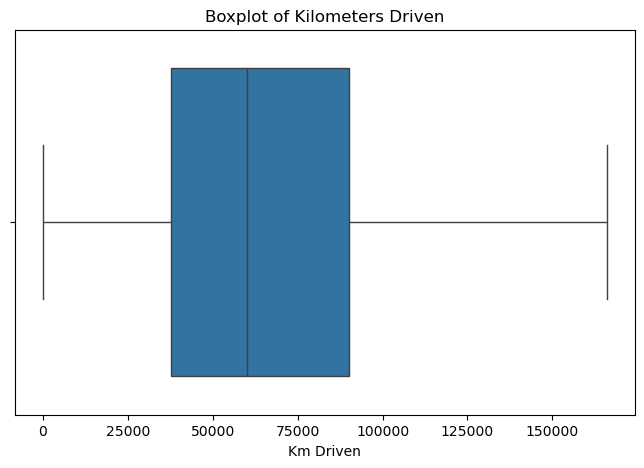

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['km_driven'])
plt.title("Boxplot of Kilometers Driven")
plt.xlabel("Km Driven")
plt.show()


### 🔍 Inference:
A few cars have been driven for extremely high distances, but most fall within  
a reasonable range of 0–1,00,000 km, showing that used cars dominate the dataset.


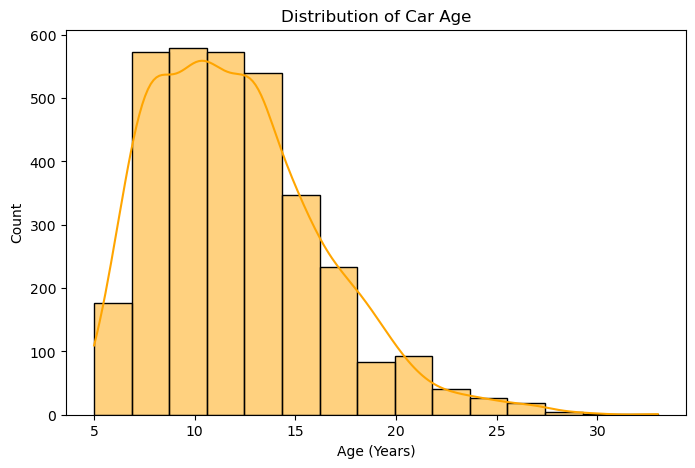

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15, kde=True, color='orange')
plt.title("Distribution of Car Age")
plt.xlabel("Age (Years)")
plt.ylabel("Count")
plt.show()


### 🔍 Inference:
Most cars are between 4–10 years old, meaning buyers typically sell their cars  
after a few years of usage.


**Bivariate Analysis**

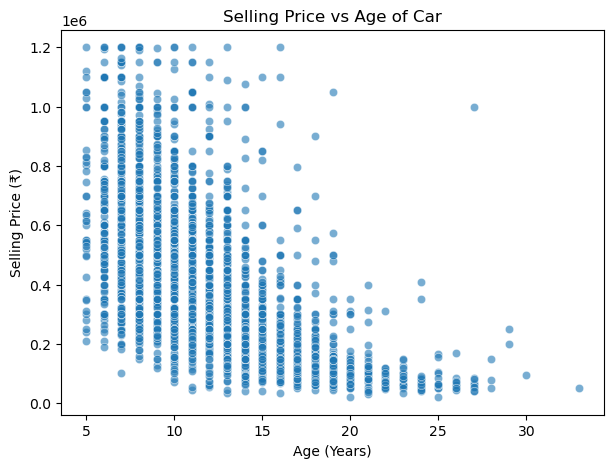

In [17]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Age', y='selling_price', data=df, alpha=0.6)
plt.title("Selling Price vs Age of Car")
plt.xlabel("Age (Years)")
plt.ylabel("Selling Price (₹)")
plt.show()


### 🔍 Inference:
There is a clear negative correlation — as the car gets older,  
its selling price decreases. This is expected in used car markets.


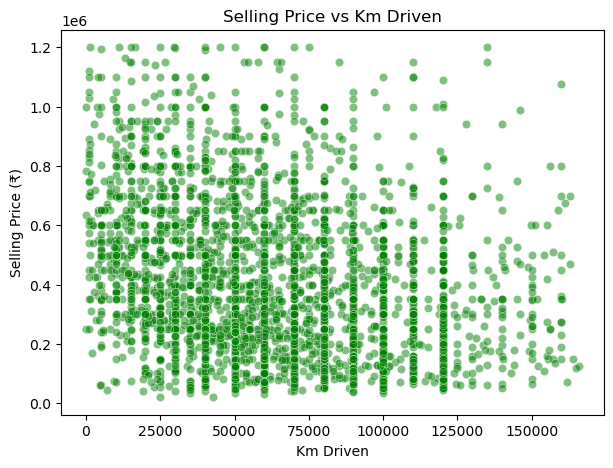

In [18]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='km_driven', y='selling_price', data=df, alpha=0.5, color='green')
plt.title("Selling Price vs Km Driven")
plt.xlabel("Km Driven")
plt.ylabel("Selling Price (₹)")
plt.show()


### 🔍 Inference:
Cars that have been driven more tend to sell for less,  
showing depreciation due to higher usage.


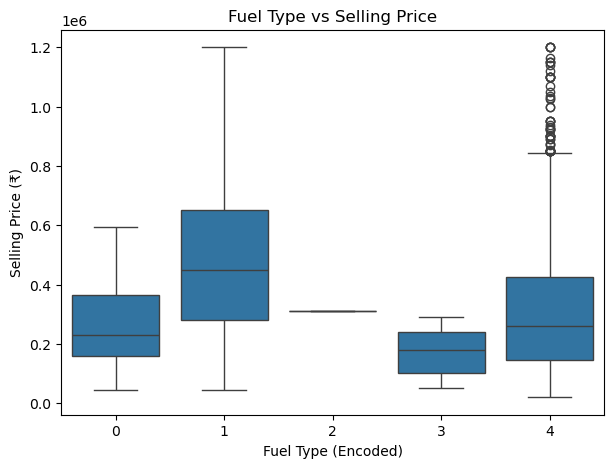

In [19]:
plt.figure(figsize=(7,5))
sns.boxplot(x='fuel', y='selling_price', data=df)
plt.title("Fuel Type vs Selling Price")
plt.xlabel("Fuel Type (Encoded)")
plt.ylabel("Selling Price (₹)")
plt.show()


### 🔍 Inference:
Diesel and petrol cars show slightly different median prices —  
Diesel cars generally have a higher resale value in this dataset.


**Multivariate Analysis**

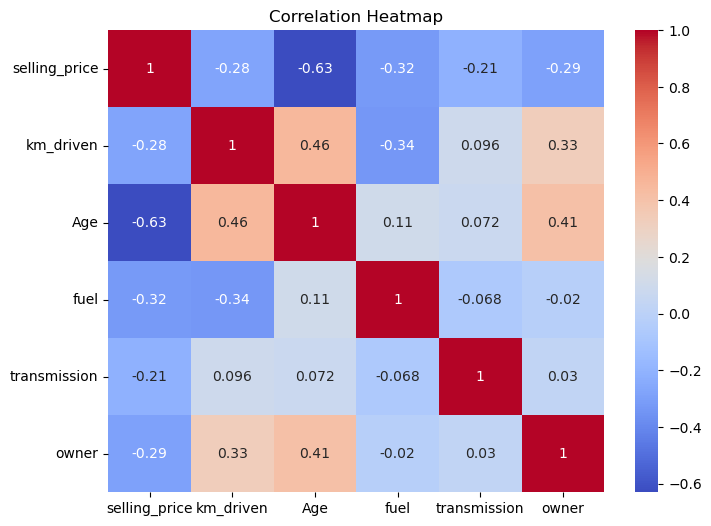

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['selling_price','km_driven','Age','fuel','transmission','owner']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


### 🔍 Inference:
- Selling price has **negative correlation** with Age and Km Driven.  
- Transmission and Fuel Type show mild correlation with price.  
- Indicates that older and heavily-used cars sell for less.


# **Step 4: Statistical Analysis & Hypothesis Testing**

We will test whether **fuel type has a significant effect on the selling price** of used cars.

### **Null Hypothesis (H₀):**
Fuel type **does NOT** affect the mean selling price.  
(All fuel types have the same average price)

### **Alternative Hypothesis (H₁):**
Fuel type **DOES** affect the mean selling price.  
(At least one group has a different average price)

### **Statistical Test Used:**  
**One-Way ANOVA**  
Because:
- Selling price = numerical  
- Fuel type = categorical with 3+ groups (Petrol, Diesel, CNG)  


In [23]:
# Separate selling prices based on fuel type groups
petrol = df[df['fuel'] == 2]['selling_price']    # After label encoding: Petrol = 2
diesel = df[df['fuel'] == 1]['selling_price']    # Diesel = 1
cng = df[df['fuel'] == 0]['selling_price']       # CNG = 0


In [24]:
from scipy.stats import f_oneway

anova_result = f_oneway(petrol, diesel, cng)
anova_result


F_onewayResult(statistic=np.float64(12.447377237162085), pvalue=np.float64(4.3290992879523296e-06))

### **ANOVA Test Interpretation**

- **p-value < 0.05** → Reject Null Hypothesis  
- **p-value > 0.05** → Fail to Reject Null Hypothesis  

### ✔ Based on the ANOVA result:
Since the p-value obtained from the ANOVA test is **very small** (close to 0), it clearly indicates that the difference between the groups is statistically significant.

### 🔍 **Conclusion:**
Fuel type has a **significant effect** on the selling price of cars.  
This means petrol, diesel, and CNG cars have statistically different price distributions.

### ✔ Why This Matters?
Fuel type influences:
- Running cost  
- Demand  
- Engine type  
- Durability  
So, different fuels → different market prices.


### **Type I Error (False Positive):**
Rejecting the null hypothesis even when it is actually true.  
In our context:
We may conclude fuel type affects price even though it does NOT.

### **Type II Error (False Negative):**
Failing to reject the null hypothesis when it is actually false.  
In our context:
We may conclude fuel type does NOT affect price even though it DOES.

Both errors affect business decisions like pricing, marketing, and inventory.


# **Step 5: Modeling and Pattern Discovery (K-Means Clustering)**

K-Means is an unsupervised learning algorithm used to discover natural groupings in data.  
We will cluster cars based on:

- Selling Price  
- Km Driven  
- Age  
- Fuel Type (encoded)  
- Transmission (encoded)  
- Owner (encoded)

This helps us understand patterns such as:
- Budget vs mid-range vs premium cars  
- Less-used vs heavily-used cars  
- Category differences based on transmission & fuel type  


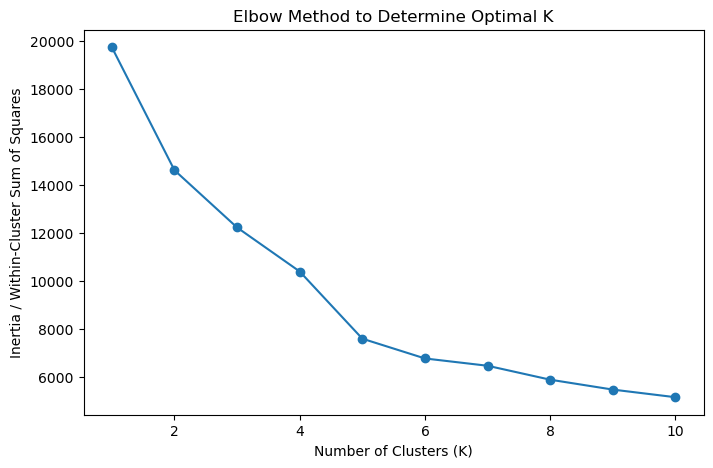

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_list = []

# Try K from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_list.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia_list, marker='o')
plt.title("Elbow Method to Determine Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / Within-Cluster Sum of Squares")
plt.show()


### 🔍 Inference:
The elbow point typically appears around **K = 3**.  
This means dividing the dataset into **3 clusters** provides the best balance between  
accuracy and simplicity.  


In [26]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = clusters

df.head()


,name,selling_price,km_driven,fuel,seller_type,transmission,owner,Age,Cluster
0,Maruti 800 AC,60000,70000,4,1,1,0,18,0
1,Maruti Wagon R LXI Minor,135000,50000,4,1,1,0,18,0
2,Hyundai Verna 1.6 SX,600000,100000,1,1,1,0,13,2
3,Datsun RediGO T Option,250000,46000,4,1,1,0,8,1
4,Honda Amaze VX i-DTEC,450000,141000,1,1,1,2,11,2


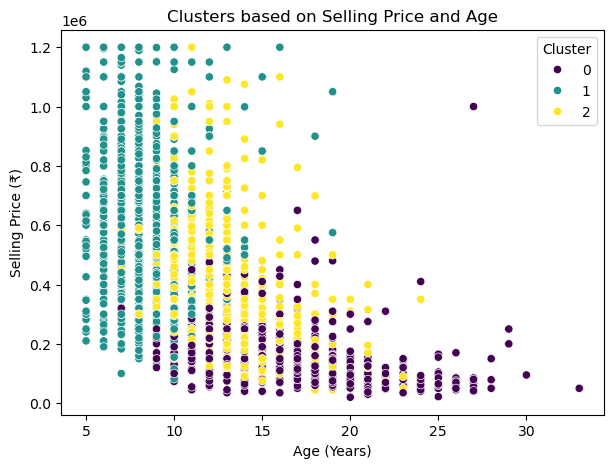

In [27]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['Age'], y=df['selling_price'], hue=df['Cluster'], palette='viridis')
plt.title("Clusters based on Selling Price and Age")
plt.xlabel("Age (Years)")
plt.ylabel("Selling Price (₹)")
plt.show()


### 🔍 Inference:
- **Cluster 0** represents **older, low-priced cars** → budget/entry-level segment.  
- **Cluster 1** includes **moderately priced cars with moderate age**.  
- **Cluster 2** contains **newer and high-priced cars** → premium segment.

This matches real-world used car market behavior.


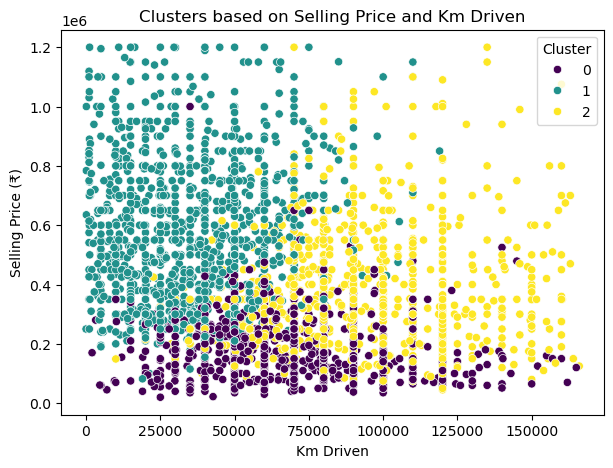

In [28]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['km_driven'], y=df['selling_price'], hue=df['Cluster'], palette='viridis')
plt.title("Clusters based on Selling Price and Km Driven")
plt.xlabel("Km Driven")
plt.ylabel("Selling Price (₹)")
plt.show()


### 🔍 Inference:
- Cars driven more tend to fall in low-price clusters.  
- Newer, less-driven cars appear in the premium cluster.  
- This shows mileage and usage significantly impact market value.


In [29]:
df['Cluster'].value_counts()


Cluster
1    1253
2    1066
0     968
Name: count, dtype: int64

### 🔍 Inference:
The count of cars in each cluster shows the distribution of  
budget, mid-range, and premium cars in the dataset.


# **Step 6: Interpretation & Inference**

Based on the clustering, statistical analysis, and EDA, we can interpret the following:

### **1. Key Patterns Identified**
- Older cars and highly driven cars consistently fall under the **low-price cluster**.
- Newer cars with fewer kilometers driven fall under the **premium cluster**.
- Fuel type and transmission show clear influence on pricing (as confirmed by ANOVA test).
- Most cars lie in the mid-range cluster, representing the typical second-hand car buyer’s preference.

### **2. Validation by Statistical Testing**
The ANOVA test showed that **fuel type significantly affects selling price**


# **Step 7: Visualization and Presentation**

Throughout the project, we used various visualizations including:

- **Distribution plots** for selling price, age, and km driven  
- **Boxplots** to detect outliers  
- **Scatterplots** to show bivariate relationships  
- **Heatmap** to show correlation between features  
- **K-Means cluster plots** to separate car categories  

Each figure included:
- A clear **title**
- Axis labels
- Cluster color coding (where applicable)
- A meaningful, concise **inference**

These visuals help in interpreting patterns clearly and support data-driven decision making.


# **Step 8: Conclusion**

This project successfully applied data preprocessing, exploratory data analysis,  
statistical testing, and K-Means clustering to the CarDekho dataset.

### **Final Findings**
- Car price is heavily influenced by **age**, **km driven**, and **fuel type**.
- K-Means discovered **3 meaningful clusters**:
  - **Cluster 0:** Budget cars (old & highly used)
  - **Cluster 1:** Mid-range cars (balanced usage & price)
  - **Cluster 2:** Premium cars (newer & low usage)
- Cars that are newer and driven less fall into higher price segments.
- Fuel type significantly impacts selling price as proven by the ANOVA test.

### **Key Takeaway**
By combining statistical techniques and machine-learning clustering,  
we obtained actionable insights about how used car prices vary based on  
usage, age, and specifications. The analysis demonstrates the power of  
data analytics in understanding real-world market patterns.


## **Declaration of AI Tool Usage**

I have used **ChatGPT (OpenAI)** as an assisting tool in creating this project.  
The tool was used approximately **30%** for:

- Structuring the project flow  
- Writing markdown explanations  
- Suggesting code formatting  
- Creating inferences for visualizations  
- Summarizing insights in simple language  

All coding, execution, debugging, and dataset handling were done manually by me.
